# Kaggle dataset link - 'https://www.kaggle.com/datasets/ananthu017/emotion-detection-fer'

# Import Dependencies

In [1]:
!pip install -q ultralytics split-folders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00a 0:00:01


# Import Modules

In [2]:
from ultralytics import YOLO

import splitfolders

import pandas as pd
import matplotlib.pyplot as plt

import os
import shutil
import random
import cv2

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Load The Dataset

In [3]:
# Original Dataset
TRAIN_DIR = '/kaggle/input/datasets/ananthu017/emotion-detection-fer/train'
TEST_DIR  = '/kaggle/input/datasets/ananthu017/emotion-detection-fer/test'

# Final YOLO Classification Dataset
FINAL_DIR = '/kaggle/working/EmotionDataset'

# ============================================================
# REMOVE OLD DIRECTORY
# ============================================================

if os.path.exists(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)

os.makedirs(FINAL_DIR, exist_ok=True)

print("Directory Ready!")


Directory Ready!


# Data Preprocessing

In [4]:
# ============================================================
# SPLIT TRAIN -> TRAIN + VAL
# ============================================================

splitfolders.ratio(
    TRAIN_DIR,
    output=FINAL_DIR,
    seed=42,
    ratio=(0.9, 0.1)
)

print("Train/Val Split Done!")

Copying files: 28709 files [04:29, 106.44 files/s]

Train/Val Split Done!


In [5]:
# ============================================================
# COPY ORIGINAL TEST FOLDER
# ============================================================

shutil.copytree(
    TEST_DIR,
    os.path.join(FINAL_DIR, 'test')
)

print("Test Folder Copied!")

Test Folder Copied!


In [6]:
# FINAL DATASET STRUCTURE
# ============================================================

# EmotionDataset/
#     train/
#     val/
#     test/

print("\nFinal Dataset Ready At:")
print(FINAL_DIR)


Final Dataset Ready At:
/kaggle/working/EmotionDataset


In [7]:
# ============================================================
# CHECK TOTAL IMAGES
# ============================================================

for split in ['train', 'val', 'test']:

    split_path = os.path.join(FINAL_DIR, split)

    total_images = 0

    print(f"\n========== {split.upper()} ==========")

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):

            count = len(os.listdir(class_path))

            total_images += count

            print(f"{class_name}: {count}")

    print(f"\nTotal Images: {total_images}")



========== TRAIN ==========
disgusted: 392
surprised: 2853
neutral: 4468
happy: 6493
fearful: 3687
angry: 3595
sad: 4347

Total Images: 25835

========== VAL ==========
disgusted: 44
surprised: 318
neutral: 497
happy: 722
fearful: 410
angry: 400
sad: 483

Total Images: 2874

========== TEST ==========
disgusted: 111
surprised: 831
neutral: 1233
happy: 1774
fearful: 1024
angry: 958
sad: 1247

Total Images: 7178


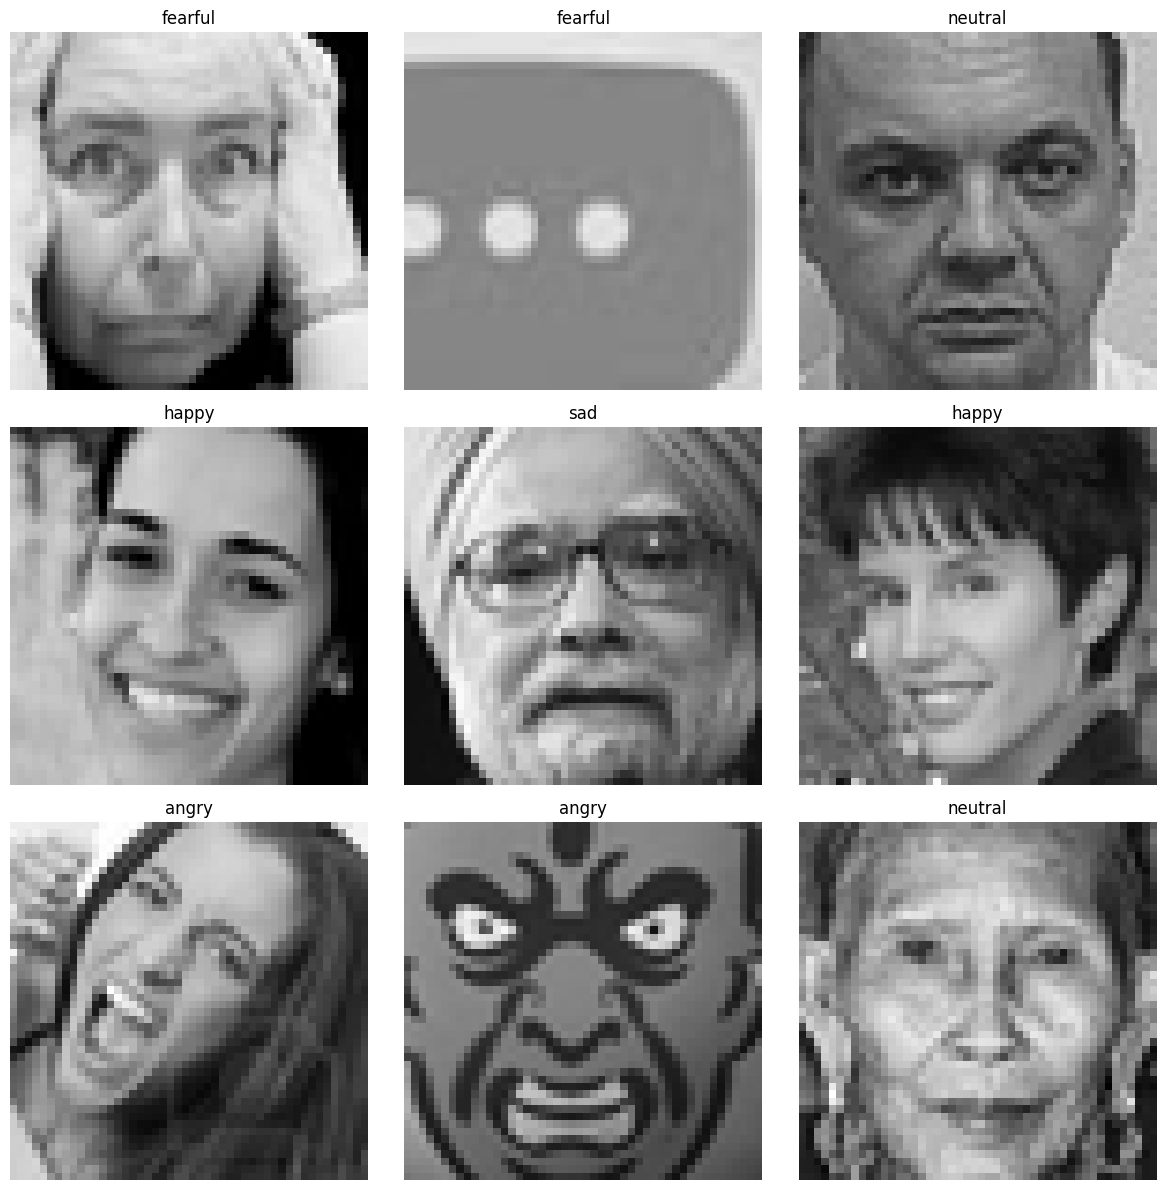

In [8]:
# ============================================================
# VISUALIZE RANDOM TRAIN IMAGES
# ============================================================

TRAIN_DATA_DIR = f'{FINAL_DIR}/train'

all_images = []

for class_name in os.listdir(TRAIN_DATA_DIR):

    class_path = os.path.join(TRAIN_DATA_DIR, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        all_images.append((image_path, class_name))

sample_images = random.sample(all_images, 9)

plt.figure(figsize=(12, 12))

for i, (image_path, class_name) in enumerate(sample_images):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)

    plt.imshow(img)

    plt.title(class_name)

    plt.axis('off')

plt.tight_layout()

plt.show()


# Model Building

In [9]:
# ============================================================
# LOAD YOLOv8 CLASSIFICATION MODEL
# ============================================================

# Options:
# yolov8n-cls.pt
# yolov8s-cls.pt
# yolov8m-cls.pt

model = YOLO('yolov8n-cls.pt')

In [11]:
# ============================================================
# TRAIN MODEL
# ============================================================

model.train(
    data=FINAL_DIR,
    epochs=20,
    imgsz=128, # 224 can be done
    batch=64,
    name='train',
    cache=True,
    exist_ok=True
)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/EmotionDataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cad28c71700>
curves: []
curves_results: []
fitness: 0.8368127942085266
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.6830201745033264, 'metrics/accuracy_top5': 0.9906054139137268, 'fitness': 0.8368127942085266}
save_dir: PosixPath('/kaggle/working/runs/classify/train')
speed: {'preprocess': 0.024687199721333923, 'inference': 0.13931892867107804, 'loss': 0.0021044004870197056, 'postprocess': 0.0001479248429851353}
top1: 0.6830201745033264
top5: 0.9906054139137268

# Good Accuracy Range

| top1_acc | Quality   |
| -------- | --------- |
| < 50%    | Weak      |
| 60–70%   | Good      |
| 70–80%   | Very Good |
| 80%+     | Excellent |


In [12]:
# ============================================================
# LOAD TRAINING RESULTS
# ============================================================

RESULTS_CSV = '/kaggle/working/runs/classify/train/results.csv'

df = pd.read_csv(RESULTS_CSV)

df.head()

,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,38.5012,1.28931,0.56889,0.97808,1.15485,0.000302,0.000302,0.000302
1,2,75.9936,1.18310,0.59186,0.98399,1.12035,0.000575,0.000575,0.000575
2,3,113.7470,1.19482,0.57864,0.98051,1.12048,0.000818,0.000818,0.000818
3,4,151.4770,1.15111,0.61134,0.98365,1.04690,0.000774,0.000774,0.000774
4,5,189.4720,1.09392,0.62665,0.98365,1.00775,0.000729,0.000729,0.000729


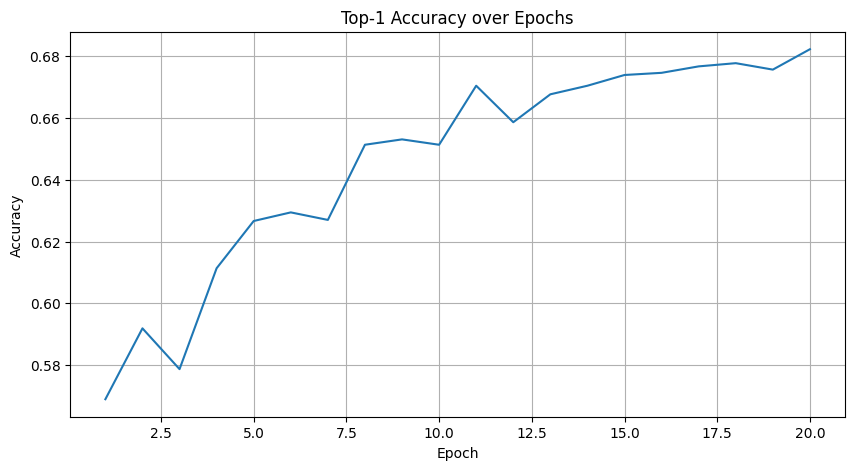

In [13]:
# ============================================================
# PLOT ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(df['epoch'], df['metrics/accuracy_top1'])

plt.title('Top-1 Accuracy over Epochs')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.grid(True)

plt.show()

# Model Evaluation

In [14]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

BEST_MODEL_PATH = '/kaggle/working/runs/classify/train/weights/best.pt'

best_model = YOLO(BEST_MODEL_PATH)

In [15]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

test_metrics = best_model.val(
    data=FINAL_DIR,
    split='test'
)

print("\nTest Metrics")
print(test_metrics)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,443,847 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/EmotionDataset/train... found 25835 images in 7 classes ✅ 
val: /kaggle/working/EmotionDataset/val... found 2874 images in 7 classes ✅ 
test: /kaggle/working/EmotionDataset/test... found 7178 images in 7 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 56.9±19.4 MB/s, size: 1.8 KB)
test: Scanning /kaggle/working/EmotionDataset/test... 7178 images, 0 corrupt: 100% ━━━━━━━━━━━━ 7178/7178 3.7Kit/s 1.9s<0.0s
test: New cache created: /kaggle/working/EmotionDataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 449/449 79.7it/s 5.6s0.1s
                   all      0.677      0.991
Speed: 0.0ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val

Test Metrics
ultralytics.utils.metrics.ClassifyMetr

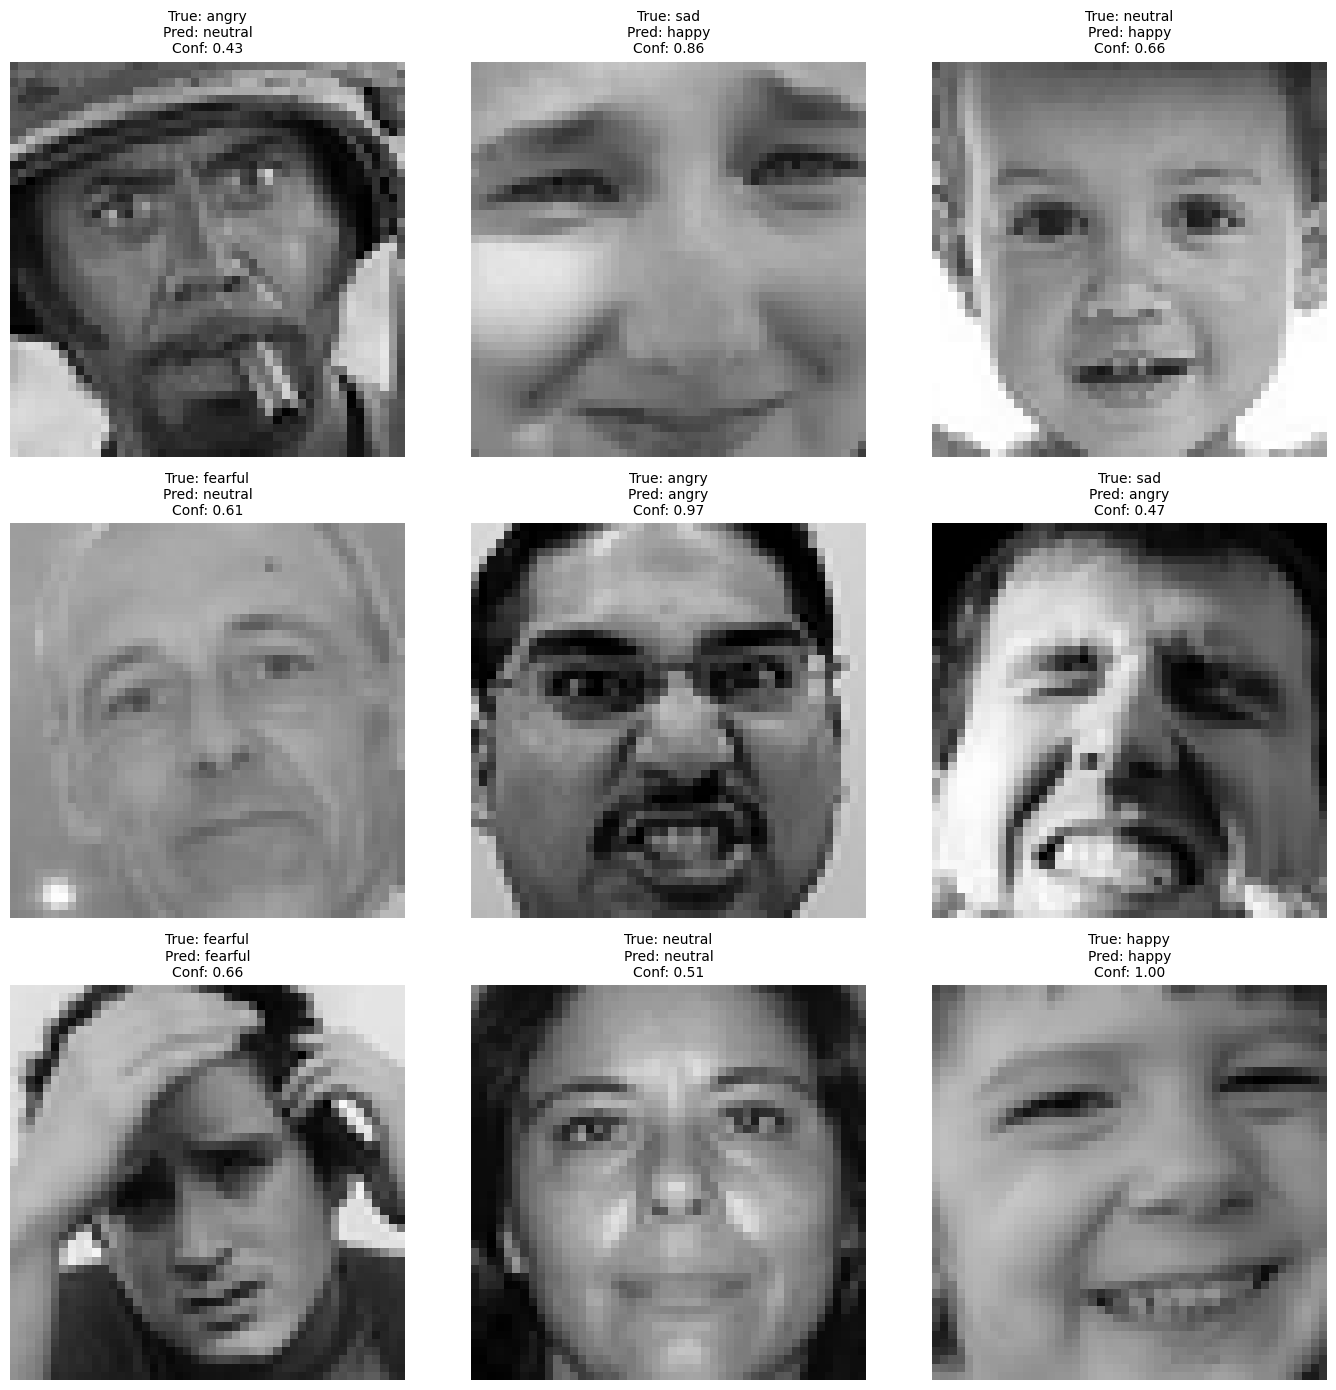

In [16]:
# ============================================================
# VISUALIZE RANDOM TEST PREDICTIONS
# ============================================================

TEST_DATA_DIR = f'{FINAL_DIR}/test'

test_images = []

for class_name in os.listdir(TEST_DATA_DIR):

    class_path = os.path.join(TEST_DATA_DIR, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        test_images.append((image_path, class_name))

sample_test_images = random.sample(test_images, 9)

plt.figure(figsize=(14, 14))

for i, (image_path, true_class) in enumerate(sample_test_images):

    # Predict
    results = best_model.predict(
        image_path,
        verbose=False
    )

    # Predicted Class
    predicted_class = results[0].names[
        results[0].probs.top1
    ]

    # Confidence
    confidence = float(
        results[0].probs.top1conf
    )

    # Read Image
    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Plot
    plt.subplot(3, 3, i + 1)

    plt.imshow(img)

    plt.title(
        f"True: {true_class}\nPred: {predicted_class}\nConf: {confidence:.2f}",
        fontsize=10
    )

    plt.axis('off')

plt.tight_layout()

plt.show()


<Figure size 1000x1000 with 0 Axes>

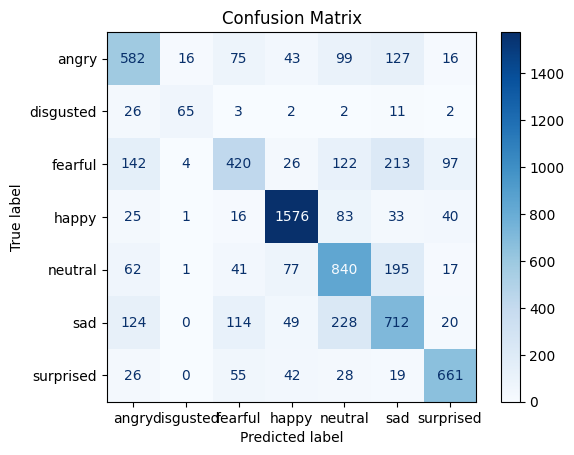

In [17]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

y_true = []
y_pred = []

for class_name in os.listdir(TEST_DATA_DIR):

    class_path = os.path.join(TEST_DATA_DIR, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        # Predict
        results = best_model.predict(
            image_path,
            verbose=False
        )

        pred_class = results[0].names[
            results[0].probs.top1
        ]

        y_true.append(class_name)

        y_pred.append(pred_class)

# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(os.listdir(TEST_DATA_DIR))
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ============================================================
# SINGLE IMAGE PREDICTION (EXTERNAL IMAGE)
# ============================================================

# ==============================
# IMAGE PATH
# ==============================

# # Change this path to your own image

# image_path = '/kaggle/input/sample-image/happy.jpg'

# image_name = os.path.basename(image_path)

# # ==============================
# # YOLO PREDICTION
# # ==============================

# results = best_model.predict(
#     image_path,
#     verbose=False
# )

# # ==============================
# # PREDICTED CLASS
# # ==============================

# predicted_class = results[0].names[
#     results[0].probs.top1
# ]

# # ==============================
# # CONFIDENCE SCORE
# # ==============================

# confidence = float(
#     results[0].probs.top1conf
# )

# # ==============================
# # READ IMAGE
# # ==============================

# img = cv2.imread(image_path)

# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# # ==============================
# # SHOW IMAGE
# # ==============================

# plt.figure(figsize=(7, 7))

# plt.imshow(img)

# plt.title(
#     f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}",
#     fontsize=12
# )

# plt.axis("off")

# plt.show()


In [18]:
# ============================================================
# SAVE MODEL PATH
# ============================================================

print("\nBest Model Saved At:")
print(BEST_MODEL_PATH)


Best Model Saved At:
/kaggle/working/runs/classify/train/weights/best.pt


In [20]:
# import urllib.request

# url = "https://github.com/andrisan/yolov8-face/releases/download/v1.0/yolov8n-face.pt"

# urllib.request.urlretrieve(
#     url,
#     "yolov8n-face.pt"
# )

# print("Downloaded!")